# 02 Feature Stats + ML (Optimized Visual Notebook)

What this notebook does:
1. Audits **every** `.mat` file in `Preprocessed/` so you can verify dataset consistency.
2. Extracts hypothesis-driven features (frontal beta, parietal/occipital alpha, focus index).
3. Computes alpha stability per trial.
4. Runs group-level repeated-measures statistics.
5. Runs LOSO baseline classification (`MD` vs `MC`).
6. Saves clean CSV outputs for report/figures.


## Summary

**Dataset:** 18 subjects, 64 channels, 512 Hz. Music conditions have thousands of epochs after windowing.

**Main hypothesis tests (group-level):**
- **Focus Index (Frontal Beta / ParOcc Alpha):** No significant condition effect in rmANOVA *(p ≈ 0.258)*.
- **Alpha Stability (STD across epochs per trial):** No significant condition effect in rmANOVA *(p ≈ 0.212)*.

**Planned comparisons (paired, subject-level means):**
- MD vs MC and MD vs MF are **not significant** after correction in this run.

**Baseline ML (MD vs MC):**
- Leave-One-Subject-Out accuracy ≈ **0.509** and AUC ≈ **0.508**, i.e. **near chance**, suggesting these simple bandpower features do not robustly generalize across people for this dataset.

**Interpretation:** With the current feature definition (cluster-averaged Welch bandpower) and epoching, we do **not** detect a reliable linguistic-interference effect on these metrics. This is still a valid scientific result; in the Discussion we outline plausible reasons and next steps.

## 1) Setup

Why this step matters:
- Keeps all parameters in one place.
- Makes reruns easy and reproducible.


In [14]:
import os
import re
import glob
from pathlib import Path
from scipy.stats import ttest_rel
import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import welch
from scipy.stats import ttest_rel, rankdata
from statsmodels.stats.anova import AnovaRM
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


CFG = {
    "data_dir": "../Preprocessed",
    "channel_list": "../channel_list.mat",
    "out_dir": "outputs_visual",
    "epoch_sec": 2.0,
    "overlap": 0.5,
    "nperseg_sec": 2.0,
    "alpha_band": (8.0, 12.0),
    "beta_band": (13.0, 30.0),
}

MUSIC_CONDITIONS = ("MC", "MD", "MF")
FRONTAL_CHANNELS = ("F3", "F4", "FZ")
PAROCC_CHANNELS = ("P3", "P4", "PZ", "O1", "O2")

Path(CFG["out_dir"]).mkdir(parents=True, exist_ok=True)
mat_files = sorted(glob.glob(os.path.join(CFG["data_dir"], "S*_preprocessed.mat")))

print("Found subject files:", len(mat_files))
print("Example:", [os.path.basename(f) for f in mat_files[:3]])
print("Output dir:", CFG["out_dir"])


Found subject files: 18
Example: ['S10_preprocessed.mat', 'S11_preprocessed.mat', 'S12_preprocessed.mat']
Output dir: outputs_visual


## 2) Helper Functions

Why this step matters:
- Centralizes parsing and feature logic so later cells stay short.
- Avoids repeated code blocks.


In [2]:
def parse_subject_from_path(path: str) -> str:
    m = re.search(r"(S\d+)_preprocessed\.mat$", os.path.basename(path))
    return m.group(1) if m else "UNK"


def parse_condition(label: str) -> str:
    m = re.search(r"_(MC|MD|MF|SD|SF)\.$", str(label))
    return m.group(1) if m else "UNK"


def parse_song_id(label: str):
    m = re.match(r"^(\d+)_", str(label))
    return int(m.group(1)) if m else None


def _flatten_str(obj) -> str:
    if isinstance(obj, np.ndarray):
        if obj.size == 0:
            return ""
        return _flatten_str(obj.flat[0])
    return str(obj).strip()


def load_channel_names(channel_list_mat: str):
    mat = scipy.io.loadmat(channel_list_mat, simplify_cells=True)
    raw = mat.get("ch_list")
    if raw is None:
        raise ValueError("channel_list.mat missing key 'ch_list'")
    return [_flatten_str(x).upper() for x in np.asarray(raw).ravel()]


def get_channel_indices(ch_names, wanted):
    idx_map = {c.upper(): i for i, c in enumerate(ch_names)}
    found, missing = [], []
    for ch in wanted:
        if ch.upper() in idx_map:
            found.append(idx_map[ch.upper()])
        else:
            missing.append(ch)
    return found, missing


def ensure_channels_first(eeg: np.ndarray, n_channels: int) -> np.ndarray:
    if eeg.ndim != 2:
        raise ValueError("EEG must be 2D")
    if eeg.shape[0] == n_channels:
        return eeg
    if eeg.shape[1] == n_channels:
        return eeg.T
    raise ValueError(f"EEG shape incompatible with channel count: {eeg.shape}")


def epoch_starts(n_samples: int, epoch_samples: int, step_samples: int) -> np.ndarray:
    if n_samples < epoch_samples:
        return np.array([], dtype=int)
    return np.arange(0, n_samples - epoch_samples + 1, step_samples, dtype=int)


def mean_bandpower(epoch: np.ndarray, fs: float, band: tuple[float, float], nperseg: int) -> float:
    freqs, psd = welch(epoch, fs=fs, axis=-1, nperseg=nperseg)
    f_lo, f_hi = band
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    if not np.any(mask):
        return float("nan")
    return float(np.mean(psd[:, mask]))


def paired_test(df_wide: pd.DataFrame, a: str, b: str):
    pair = df_wide[[a, b]].dropna()
    x = pair[a].to_numpy()
    y = pair[b].to_numpy()
    if len(pair) < 2:
        return {"contrast": f"{a}_vs_{b}", "n_subjects": len(pair), "mean_diff": np.nan, "t": np.nan, "p": np.nan, "d": np.nan}
    t, p = ttest_rel(x, y)
    diff = x - y
    d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else np.nan
    return {"contrast": f"{a}_vs_{b}", "n_subjects": len(pair), "mean_diff": float(np.mean(diff)), "t": float(t), "p": float(p), "d": float(d)}


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    n = len(y_true)

    acc = (tp + tn) / n if n else np.nan
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    bacc = np.nanmean([sens, spec])
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    rec = sens
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else np.nan

    pos = y_true == 1
    neg = y_true == 0
    if np.any(pos) and np.any(neg):
        ranks = rankdata(y_score)
        auc = (np.sum(ranks[pos]) - np.sum(np.arange(1, np.sum(pos) + 1))) / (np.sum(pos) * np.sum(neg))
    else:
        auc = np.nan

    return {
        "n_test": int(n), "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "accuracy": float(acc), "balanced_accuracy": float(bacc),
        "precision": float(prec), "recall": float(rec), "f1": float(f1), "auc": float(auc),
    }

print("Helper functions loaded.")


Helper functions loaded.


## 3) Audit Every File in `Preprocessed/`

This cell reads all subject files and summarizes what each file includes.

Expected structure in each file:
- `Data.info`: subject metadata and sampling rates
- `Data.data`: list of trials
- each trial has: `TargetType`, `EEG`, `Engagement`, `Familiarity`, `Trial`

This step
- Confirms assumptions before feature extraction.
- Shows missing/uneven trials across subjects.


In [3]:
audit_rows = []
all_info_fields = set()
all_trial_fields = set()

for path in mat_files:
    file_name = os.path.basename(path)
    D = scipy.io.loadmat(path, simplify_cells=True)["Data"]
    info = D["info"]
    trials = D["data"]

    info_fields = tuple(sorted(info.keys()))
    all_info_fields.add(info_fields)

    cond_counts = {"MC": 0, "MD": 0, "MF": 0, "SD": 0, "SF": 0, "UNK": 0}
    trial_fields = set()
    shapes = set()

    for tr in trials:
        trial_fields.update(tr.keys())
        cond = parse_condition(tr["TargetType"])
        cond_counts[cond] = cond_counts.get(cond, 0) + 1
        shapes.add(tuple(np.asarray(tr["EEG"]).shape))

    all_trial_fields.add(tuple(sorted(trial_fields)))
    audit_rows.append({
        "file": file_name,
        "subject": info.get("subject", "UNK"),
        "age": info.get("age", np.nan),
        "gender": info.get("gender", "UNK"),
        "fs": float(info.get("EEG_fs", np.nan)),
        "nbChannel": int(info.get("nbChannel", np.nan)),
        "n_trials": len(trials),
        "eeg_shapes": str(sorted(shapes)),
        **cond_counts,
    })

audit_df = pd.DataFrame(audit_rows).sort_values("file").reset_index(drop=True)
audit_df.to_csv(os.path.join(CFG["out_dir"], "preprocessed_file_audit.csv"), index=False)

print("Files audited:", len(audit_df))
print("Unique info field schemas:", len(all_info_fields), list(all_info_fields)[0])
print("Unique trial field schemas:", len(all_trial_fields), list(all_trial_fields)[0])
print("Unique sampling rates:", sorted(audit_df["fs"].unique().tolist()))
print("Trial count range:", int(audit_df["n_trials"].min()), "to", int(audit_df["n_trials"].max()))
print()
print("Per-file condition counts (music + controls):")
print(audit_df[["file", "n_trials", "MC", "MD", "MF", "SD", "SF"]].to_string(index=False))


Files audited: 18
Unique info field schemas: 1 ('EEG_fs', 'age', 'gender', 'nbChannel', 'sound_fs', 'subject')
Unique trial field schemas: 1 ('EEG', 'Engagement', 'Familiarity', 'TargetType', 'Trial')
Unique sampling rates: [512.0]
Trial count range: 20 to 25

Per-file condition counts (music + controls):
                file  n_trials  MC  MD  MF  SD  SF
S10_preprocessed.mat        24   5   4   5   5   5
S11_preprocessed.mat        24   5   5   5   5   4
S12_preprocessed.mat        20   4   5   3   3   5
S13_preprocessed.mat        24   4   5   5   5   5
S15_preprocessed.mat        25   5   5   5   5   5
S16_preprocessed.mat        24   5   5   5   5   4
S17_preprocessed.mat        25   5   5   5   5   5
S19_preprocessed.mat        25   5   5   5   5   5
 S1_preprocessed.mat        24   5   5   5   4   5
S22_preprocessed.mat        23   4   5   5   4   5
 S2_preprocessed.mat        20   5   4   4   4   3
 S3_preprocessed.mat        25   5   5   5   5   5
 S4_preprocessed.mat        23

### Audit Interpretation
This dataset is suitable for a single standardized preprocessing + feature pipeline because:

1) **Consistent schema across subjects.** All `.mat` files share the same `Data.info` fields and the same trial field structure (`EEG`, `TargetType`, etc.). This reduces risk that a subset of subjects is parsed differently.

2) **Consistent sampling and channel count.** Sampling rate is **512 Hz** for all subjects and EEG is consistently **64 channels**. This means our fixed band definitions (alpha 8–12 Hz, beta 13–30 Hz) and epoch windowing are comparable across participants.

3) **Uneven trial counts by subject.** Subjects have **~20–25 trials**, and condition counts can vary slightly. Because of this, we rely on:
- **subject-level means** for inference (rmANOVA), and
- a **within-subject design** (repeated measures) rather than treating epochs as independent subjects.

Therefore, the dataset is internally consistent, and any null/positive findings are less likely to be artifacts of file-format inconsistencies.

## 4) Channel Mapping for Spatial Features

This maps the hypothesis electrodes from `channel_list.mat`:
- Frontal beta: `F3, F4, Fz`
- Parietal/occipital alpha: `P3, P4, Pz, O1, O2`


In [4]:
ch_names = load_channel_names(CFG["channel_list"])
frontal_idx, missing_f = get_channel_indices(ch_names, FRONTAL_CHANNELS)
parocc_idx, missing_p = get_channel_indices(ch_names, PAROCC_CHANNELS)

if missing_f or missing_p:
    raise ValueError(f"Missing channels. Frontal missing={missing_f}, ParOcc missing={missing_p}")

print("Total channels:", len(ch_names))
print("Frontal channels used:", [ch_names[i] for i in frontal_idx])
print("ParOcc channels used:", [ch_names[i] for i in parocc_idx])


Total channels: 64
Frontal channels used: ['F3', 'F4', 'FZ']
ParOcc channels used: ['P3', 'P4', 'PZ', 'O1', 'O2']


### Reasin for spatial masking (frontal beta vs parietal/occipital alpha)

Our proposal is not about “overall EEG power,” but about **where** in the scalp signal we expect changes:

- **Frontal beta (F3/F4/Fz, 13–30 Hz):** often linked to sustained attention, active task engagement, and top-down control.
- **Parietal/occipital alpha (P3/P4/Pz/O1/O2, 8–12 Hz):** often linked to cortical idling / inhibition and is commonly modulated by attention demands and sensory processing.

Therefore, we extract:
- `beta_frontal` = cluster-average beta bandpower over frontal electrodes  
- `alpha_parocc` = cluster-average alpha bandpower over parietal/occipital electrodes  
- `focus_index` = `beta_frontal / alpha_parocc` (Engagement Index)

This design directly operationalizes the “linguistic interference” hypothesis using anatomically-motivated features rather than averaging across all 64 channels.

## 5) Epoching + Feature Extraction

Per epoch:
- `beta_frontal` = mean Welch PSD in 13-30 Hz over frontal channels
- `alpha_parocc` = mean Welch PSD in 8-12 Hz over parietal/occipital channels
- `focus_index` = `beta_frontal / alpha_parocc`

Note: **epochs from the same subject are not independent samples** for hypothesis testing.  
We use epochs to compute **stable per-subject estimates** (mean Focus Index per condition) and to compute **variability-based metrics** like Alpha Stability (STD across epochs).

Per trial:
- `alpha_std`, `alpha_var` across epochs (alpha stability metrics)

Each trial is a continuous music segment. To measure within-trial dynamics and to increase the number of observations, we slice each trial into **fixed-length epochs** with overlap:

- Epoch length: **2 s**
- Overlap: **50%** (step size = 1 s)

This step converts continuous trials into repeated observations while preserving condition labels.


In [5]:
epoch_rows = []
trial_rows = []

for path in mat_files:
    subject = parse_subject_from_path(path)
    D = scipy.io.loadmat(path, simplify_cells=True)["Data"]
    fs = float(D["info"]["EEG_fs"])
    epoch_samples = int(round(CFG["epoch_sec"] * fs))
    step_samples = int(round(epoch_samples * (1.0 - CFG["overlap"])))
    nperseg = min(epoch_samples, int(round(CFG["nperseg_sec"] * fs)))

    for trial_idx, tr in enumerate(D["data"]):
        label = str(tr["TargetType"])
        condition = parse_condition(label)
        if condition not in MUSIC_CONDITIONS:
            continue

        eeg = ensure_channels_first(np.asarray(tr["EEG"], dtype=float), len(ch_names))
        starts = epoch_starts(eeg.shape[1], epoch_samples, step_samples)

        alpha_vals = []
        for ep_idx, start in enumerate(starts):
            stop = int(start + epoch_samples)
            epoch = eeg[:, start:stop]

            beta_frontal = mean_bandpower(epoch[frontal_idx, :], fs, CFG["beta_band"], nperseg)
            alpha_parocc = mean_bandpower(epoch[parocc_idx, :], fs, CFG["alpha_band"], nperseg)
            focus_index = beta_frontal / alpha_parocc if alpha_parocc > 0 else np.nan
            alpha_vals.append(alpha_parocc)

            epoch_rows.append({
                "subject": subject,
                "trial_index": trial_idx,
                "trial_label": label,
                "song_id": parse_song_id(label),
                "condition": condition,
                "epoch_index": ep_idx,
                "start_sample": int(start),
                "end_sample": int(stop),
                "beta_frontal": beta_frontal,
                "alpha_parocc": alpha_parocc,
                "focus_index": focus_index,
            })

        alpha_arr = np.asarray(alpha_vals, dtype=float)
        trial_rows.append({
            "subject": subject,
            "trial_index": trial_idx,
            "trial_label": label,
            "song_id": parse_song_id(label),
            "condition": condition,
            "n_epochs": int(alpha_arr.size),
            "alpha_mean": float(np.nanmean(alpha_arr)) if alpha_arr.size else np.nan,
            "alpha_std": float(np.nanstd(alpha_arr, ddof=1)) if alpha_arr.size > 1 else np.nan,
            "alpha_var": float(np.nanvar(alpha_arr, ddof=1)) if alpha_arr.size > 1 else np.nan,
        })

epoch_df = pd.DataFrame(epoch_rows)
trial_df = pd.DataFrame(trial_rows)

for col in ["beta_frontal", "alpha_parocc", "focus_index"]:
    epoch_df[col] = pd.to_numeric(epoch_df[col], errors="coerce")

epoch_df = epoch_df.dropna(subset=["beta_frontal", "alpha_parocc", "focus_index"])
trial_df = trial_df.dropna(subset=["alpha_std", "alpha_var"], how="all")

print("Epoch rows:", len(epoch_df))
print("Trial rows:", len(trial_df))
print()
print("Epoch counts by condition:")
print(epoch_df["condition"].value_counts().to_string())
print()
print("Epoch feature preview:")
print(epoch_df.head(5).to_string(index=False))


Epoch rows: 17940
Trial rows: 260

Epoch counts by condition:
condition
MD    6072
MC    6003
MF    5865

Epoch feature preview:
subject  trial_index trial_label  song_id condition  epoch_index  start_sample  end_sample  beta_frontal  alpha_parocc  focus_index
    S10            1       5_MF.        5        MF            0             0        1024      0.377883      0.501449     0.753582
    S10            1       5_MF.        5        MF            1           512        1536      0.343354      1.207956     0.284244
    S10            1       5_MF.        5        MF            2          1024        2048      0.317997      0.755976     0.420644
    S10            1       5_MF.        5        MF            3          1536        2560      0.328892      0.939469     0.350083
    S10            1       5_MF.        5        MF            4          2048        3072      0.311816      1.061616     0.293718


We produce two levels of data:

### A) `epoch_df` (epoch-level)
Each row is **one 2-second epoch** from one subject/trial, labeled by condition:
- `beta_frontal`: frontal cluster beta bandpower (Welch PSD mean in 13–30 Hz)
- `alpha_parocc`: parietal/occipital alpha bandpower (Welch PSD mean in 8–12 Hz)
- `focus_index`: `beta_frontal / alpha_parocc`

This table is used for:
- visualization of distributions (boxplots),
- computing subject-level means per condition,
- ML classification (MD vs MC) using LOSO.

### B) `trial_df` (trial-level)
Each row is **one trial** (a full music segment), summarized across epochs:
- `alpha_std`: standard deviation of `alpha_parocc` across epochs (**Alpha Stability**)
- `alpha_var`: variance of `alpha_parocc` across epochs

### QC checks we expect:
- Epoch counts are similar across music conditions (not exactly equal, but comparable).
- `focus_index` should be finite and positive for almost all epochs (since both bandpowers are positive).
- If `alpha_std` is systematically larger in MD, that would support the “lyrics destabilize alpha” part of the proposal.

## 6) Separate Band Power Analysis (Alpha vs Beta) 

To ensure that the beta/alpha ratio was not masking condition-specific effects, we analyze beta and alpha band power separately. The engagement index (beta/alpha) can sometimes hide changes if both bands shift in the same direction. 
Here we compare frontal beta power (13–30 Hz) and parietal/occipital alpha power (8–12 Hz) independently between the MC (instrumental) and MD (understood lyrics) conditions using subject-level averages and paired statistical tests. This allows us to check whether either band alone shows systematic changes related to linguistic processing.

Beta power comparison (MD vs MC)
TtestResult(statistic=np.float64(2.0173134215651394), pvalue=np.float64(0.059736135813061884), df=np.int64(17))

Alpha power comparison (MD vs MC)
TtestResult(statistic=np.float64(1.2663982465489168), pvalue=np.float64(0.2224486277054455), df=np.int64(17))


C:\Users\ramir\AppData\Local\Temp\ipykernel_22284\3091556607.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([beta_MC, beta_MD], labels=["MC","MD"])
C:\Users\ramir\AppData\Local\Temp\ipykernel_22284\3091556607.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([alpha_MC, alpha_MD], labels=["MC","MD"])


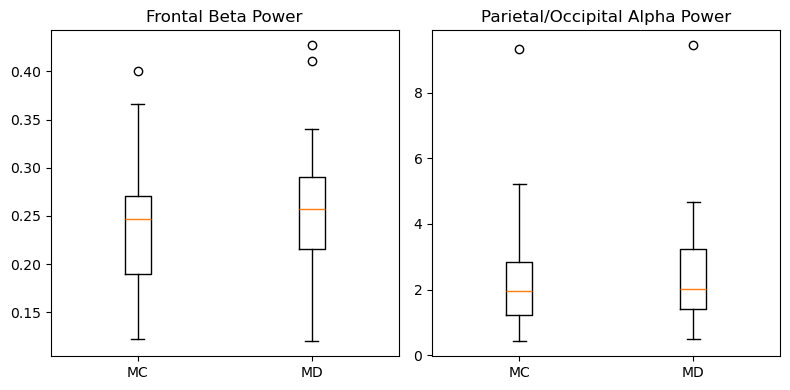


Mean Beta Power
MC: 0.2422289589997357
MD: 0.2559938206146752

Mean Alpha Power
MC: 2.494897886900221
MD: 2.6250763697575232

Beta power paired t-test
t = 2.0173134215651394
p = 0.059736135813061884

Alpha power paired t-test
t = 1.2663982465489168
p = 0.2224486277054455


In [18]:
# Keep only MD vs MC trials
df = epoch_df[epoch_df["condition"].isin(["MD","MC"])].copy()

# Average per subject per condition
subj_means = (
    df.groupby(["subject","condition"])[["beta_frontal","alpha_parocc"]]
    .mean()
    .reset_index()
)

# Pivot to align conditions
pivot = subj_means.pivot(index="subject", columns="condition")

beta_MD = pivot["beta_frontal"]["MD"]
beta_MC = pivot["beta_frontal"]["MC"]

alpha_MD = pivot["alpha_parocc"]["MD"]
alpha_MC = pivot["alpha_parocc"]["MC"]

# Paired t-tests
beta_t = ttest_rel(beta_MD, beta_MC)
alpha_t = ttest_rel(alpha_MD, alpha_MC)

print("Beta power comparison (MD vs MC)")
print(beta_t)

print("\nAlpha power comparison (MD vs MC)")
print(alpha_t)

# Quick visualization
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.boxplot([beta_MC, beta_MD], labels=["MC","MD"])
plt.title("Frontal Beta Power")

plt.subplot(1,2,2)
plt.boxplot([alpha_MC, alpha_MD], labels=["MC","MD"])
plt.title("Parietal/Occipital Alpha Power")

plt.tight_layout()
plt.show()

print("\nMean Beta Power")
print("MC:", beta_MC.mean())
print("MD:", beta_MD.mean())

print("\nMean Alpha Power")
print("MC:", alpha_MC.mean())
print("MD:", alpha_MD.mean())

# Paired t-tests
beta_t, beta_p = ttest_rel(beta_MD, beta_MC)
alpha_t, alpha_p = ttest_rel(alpha_MD, alpha_MC)

print("\nBeta power paired t-test")
print("t =", beta_t)
print("p =", beta_p)

print("\nAlpha power paired t-test")
print("t =", alpha_t)
print("p =", alpha_p)

## 7) Quick Descriptive Summaries

Why this step matters:
- Checks the central tendency and spread of each metric by condition.
- Helps interpret statistical tests later.


In [6]:
desc = epoch_df.groupby("condition")[["beta_frontal", "alpha_parocc", "focus_index"]].agg(["mean", "std", "median"])
print(desc.round(6).to_string())

subj_cond_focus = (
    epoch_df.groupby(["subject", "condition"], as_index=False)["focus_index"]
    .mean()
    .sort_values(["subject", "condition"])
)
subj_cond_alpha = (
    trial_df.groupby(["subject", "condition"], as_index=False)[["alpha_std", "alpha_var"]]
    .mean()
    .sort_values(["subject", "condition"])
)

print()
print("Subjects with all MC/MD/MF for focus:", int((subj_cond_focus.groupby("subject")["condition"].nunique() == 3).sum()))
print("Subjects with all MC/MD/MF for alpha stability:", int((subj_cond_alpha.groupby("subject")["condition"].nunique() == 3).sum()))


          beta_frontal                     alpha_parocc                     focus_index                    
                  mean       std    median         mean       std    median        mean       std    median
condition                                                                                                  
MC            0.241679  0.125645  0.212746     2.514317  3.240459  1.445408    0.194089  0.170397  0.150341
MD            0.255447  0.144907  0.223569     2.555795  3.308865  1.511224    0.206371  0.218904  0.152589
MF            0.249615  0.135511  0.216688     2.292439  3.038187  1.402512    0.217600  0.198803  0.163078

Subjects with all MC/MD/MF for focus: 18
Subjects with all MC/MD/MF for alpha stability: 18


Before inferential statistics, we check whether the **direction** of effects matches the hypothesis.

In this run:
- **Frontal beta** means are similar across conditions, with MD slightly higher than MC.
- **ParOcc alpha** means are also similar across conditions.
- **Focus Index** (beta/alpha) shows only small differences across MC/MD/MF.

These descriptive differences are **not large**, so if we see null results in rmANOVA, it is consistent with the effect size being small relative to between-subject variability.

**key takeaway** :At the descriptive level, the expected strong drop in Focus Index for MD vs MC is not clearly visible, motivating a careful statistical test and a discussion of potential confounds/limitations.

## 8) Visual Checks 

These plots help answer:
- Is focus index lower in `MD` vs `MC`?
- Is alpha stability (`alpha_std`) higher in `MD`?


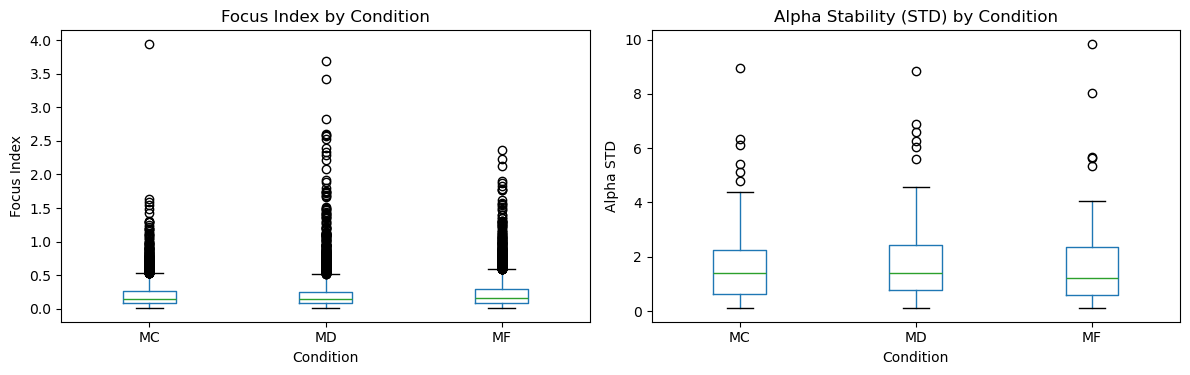

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_df.boxplot(column="focus_index", by="condition", ax=axes[0], grid=False)
axes[0].set_title("Focus Index by Condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Focus Index")

trial_df.boxplot(column="alpha_std", by="condition", ax=axes[1], grid=False)
axes[1].set_title("Alpha Stability (STD) by Condition")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Alpha STD")

plt.suptitle("")
plt.tight_layout()
plt.show()


The boxplots above show the distribution of the two main metrics across the three music conditions:

- **MC** – Instrumental music (baseline)
- **MD** – Music with understood Danish lyrics (high linguistic interference)
- **MF** – Music with Finnish lyrics (acoustic interference but not understood)

### 1. Focus Index (Frontal Beta / Parietal Alpha)

The Focus Index is intended to reflect **task engagement**, where higher values indicate relatively stronger frontal beta activity compared to parietal/occipital alpha.

From the plot we observe:

- The **median Focus Index values are very similar across MC, MD, and MF**.
- The **spread (interquartile range)** of the distributions is also very similar across conditions.
- There are **many high-value outliers**, but they occur in all three conditions rather than being concentrated in one.

**Interpretation**

There is **no clear visual separation between the conditions**. If understood lyrics strongly disrupted focus, we would expect **MD to show noticeably lower Focus Index values than MC**, but this pattern is not clearly visible in the plot.

This suggests that **any potential effect of lyrical interference on the Focus Index is small relative to the overall variability of the EEG data**.


### 2. Alpha Stability (Standard Deviation of Alpha Power)

Alpha stability measures how much **alpha power fluctuates across epochs within a trial**.

From the plot we observe:

- The **median alpha STD values are again very similar across MC, MD, and MF**.
- MD appears to have **slightly larger variability**, but the distributions **overlap heavily**.
- Several large outliers appear in all conditions.

**Interpretation**

If understood lyrics caused stronger cognitive interference, we would expect **MD to show consistently higher alpha variability** compared to MC. However, the plot shows **substantial overlap between all conditions**, suggesting that alpha stability is not dramatically different across the three types of audio.


### 3. Overall 

Taken together, the visualizations suggest that:

- The **Focus Index does not show a strong condition-dependent shift**.
- **Alpha stability also appears broadly similar across conditions**.
- The large number of overlapping values indicates that **within-subject and within-trial variability is high compared to the potential effect of lyrical interference**.

Because visual inspection alone cannot determine statistical significance, the next step is to perform **group-level statistical tests (repeated-measures ANOVA and paired comparisons)** to determine whether any subtle differences between conditions are statistically reliable.

## Subject-level paired effects

The boxplots above show the **distribution across trials/epochs**, but they do not clearly show the
**within-subject** change across conditions.

Because this experiment is **within-subject** (each participant listened to MC, MD, and MF),
the most informative visualization is a *paired subject plot*:

- Each line corresponds to **one subject**.
- Each point is that subject’s **mean metric** in a condition.
- If a condition has a systematic effect, we would expect to see a consistent
  direction across subjects (e.g., most lines slope downward from MC → MD).

These plots visually align with the rmANOVA that follows, which is also computed on
**subject-level means** (not treating epochs as independent subjects).

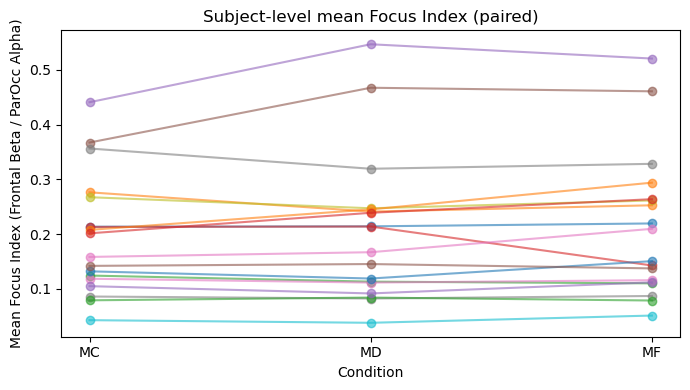

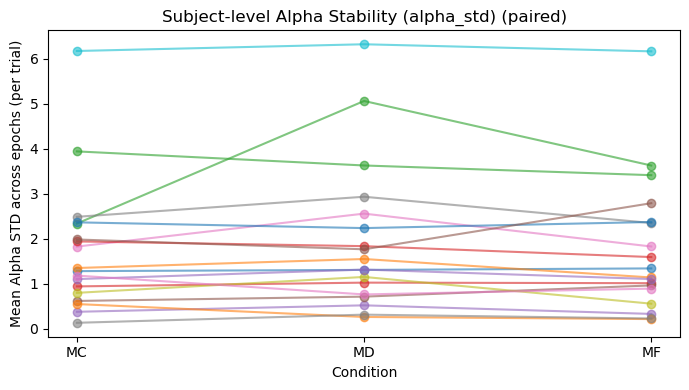

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
MC,18.0,0.196355,0.109535,0.043131,0.120160,0.180019,0.253998,0.440733
MD,18.0,0.204891,0.133720,0.038336,0.112152,0.190541,0.244209,0.546479
MF,18.0,0.211016,0.129845,0.051544,0.113097,0.180274,0.263281,0.520419


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
MC,18.0,1.745294,1.447389,0.134427,0.835598,1.317019,2.250599,6.173032
MD,18.0,1.960670,1.645605,0.263993,0.830143,1.434072,2.479538,6.322639
MF,18.0,1.775072,1.506460,0.216963,0.911522,1.241945,2.368319,6.165281


In [8]:
# --- Subject-level paired plots (spaghetti plots) ---
# Focus Index: average across epochs -> subject x condition
subj_focus = epoch_df.groupby(["subject", "condition"], as_index=False)["focus_index"].mean()

# Alpha Stability: average across trials -> subject x condition
subj_alpha = trial_df.groupby(["subject", "condition"], as_index=False)["alpha_std"].mean()

# Keep only subjects with all 3 conditions to make paired plots fair
keep_focus = subj_focus.groupby("subject")["condition"].nunique()
keep_focus = keep_focus[keep_focus == 3].index
subj_focus = subj_focus[subj_focus["subject"].isin(keep_focus)].copy()

keep_alpha = subj_alpha.groupby("subject")["condition"].nunique()
keep_alpha = keep_alpha[keep_alpha == 3].index
subj_alpha = subj_alpha[subj_alpha["subject"].isin(keep_alpha)].copy()

# Pivot to wide for easy plotting
focus_wide = subj_focus.pivot(index="subject", columns="condition", values="focus_index")[["MC", "MD", "MF"]]
alpha_wide = subj_alpha.pivot(index="subject", columns="condition", values="alpha_std")[["MC", "MD", "MF"]]

# Plot: Focus Index paired
plt.figure(figsize=(7,4))
for s in focus_wide.index:
    plt.plot(["MC", "MD", "MF"], focus_wide.loc[s].values, marker="o", alpha=0.6)
plt.title("Subject-level mean Focus Index (paired)")
plt.xlabel("Condition")
plt.ylabel("Mean Focus Index (Frontal Beta / ParOcc Alpha)")
plt.tight_layout()
plt.show()

# Plot: Alpha Stability paired
plt.figure(figsize=(7,4))
for s in alpha_wide.index:
    plt.plot(["MC", "MD", "MF"], alpha_wide.loc[s].values, marker="o", alpha=0.6)
plt.title("Subject-level Alpha Stability (alpha_std) (paired)")
plt.xlabel("Condition")
plt.ylabel("Mean Alpha STD across epochs (per trial)")
plt.tight_layout()
plt.show()

# Optional: quick summary table for the paired plots
display(focus_wide.describe().T)
display(alpha_wide.describe().T)

If lyrics had a robust effect, we would expect most subjects to shift in the same direction
between conditions (e.g., MC → MD). In our run, the lines show **mixed directions** across subjects,
and the condition-wise averages are close together.

This pattern suggests that any condition effect is **small relative to inter-subject variability**,
which is consistent with weak/null group-level effects in rmANOVA and near-chance LOSO classification.

## 9) Group-Level Statistics (rmANOVA + Planned Post-hoc)

Tests run:
- rmANOVA on subject-level `focus_index` across `MC`, `MD`, `MF`
- rmANOVA on subject-level `alpha_std` across `MC`, `MD`, `MF`
- planned paired t-tests: `MD vs MC`, `MD vs MF`


In [9]:
# Keep only subjects with complete MC/MD/MF for repeated-measures validity
keep_focus = subj_cond_focus.groupby("subject")["condition"].nunique()
keep_focus = keep_focus[keep_focus == 3].index
focus_complete = subj_cond_focus[subj_cond_focus["subject"].isin(keep_focus)].copy()

keep_alpha = subj_cond_alpha.groupby("subject")["condition"].nunique()
keep_alpha = keep_alpha[keep_alpha == 3].index
alpha_complete = subj_cond_alpha[subj_cond_alpha["subject"].isin(keep_alpha)].copy()

# Focus Index rmANOVA
focus_aov = AnovaRM(focus_complete, depvar="focus_index", subject="subject", within=["condition"]).fit()
focus_aov_tbl = focus_aov.anova_table.reset_index().rename(columns={"index": "effect"})

focus_wide = focus_complete.pivot(index="subject", columns="condition", values="focus_index")
focus_posthoc = pd.DataFrame([
    paired_test(focus_wide, "MD", "MC"),
    paired_test(focus_wide, "MD", "MF"),
])
focus_posthoc["p_bonferroni"] = np.minimum(focus_posthoc["p"] * 2, 1.0)

# Alpha stability rmANOVA
alpha_aov = AnovaRM(alpha_complete, depvar="alpha_std", subject="subject", within=["condition"]).fit()
alpha_aov_tbl = alpha_aov.anova_table.reset_index().rename(columns={"index": "effect"})

alpha_wide = alpha_complete.pivot(index="subject", columns="condition", values="alpha_std")
alpha_posthoc = pd.DataFrame([
    paired_test(alpha_wide, "MD", "MC"),
    paired_test(alpha_wide, "MD", "MF"),
])
alpha_posthoc["p_bonferroni"] = np.minimum(alpha_posthoc["p"] * 2, 1.0)

print("Focus Index rmANOVA")
print(focus_aov_tbl.to_string(index=False))
print()
print("Focus Index post-hoc")
print(focus_posthoc.to_string(index=False))
print()
print("Alpha Stability rmANOVA")
print(alpha_aov_tbl.to_string(index=False))
print()
print("Alpha Stability post-hoc")
print(alpha_posthoc.to_string(index=False))


Focus Index rmANOVA
   effect  F Value  Num DF  Den DF   Pr > F
condition 1.410353     2.0    34.0 0.257974

Focus Index post-hoc
contrast  n_subjects  mean_diff         t        p         d  p_bonferroni
MD_vs_MC          18   0.008536  0.920139 0.370373  0.216879      0.740746
MD_vs_MF          18  -0.006125 -0.974952 0.343254 -0.229798      0.686508

Alpha Stability rmANOVA
   effect  F Value  Num DF  Den DF   Pr > F
condition 1.623591     2.0    34.0 0.212106

Alpha Stability post-hoc
contrast  n_subjects  mean_diff        t        p        d  p_bonferroni
MD_vs_MC          18   0.215376 1.327828 0.201790 0.312972      0.403579
MD_vs_MF          18   0.185598 1.584488 0.131507 0.373467      0.263015


### Focus Index rmANOVA
The repeated-measures ANOVA testing `focus_index` across **MC, MD, MF** is **not significant** in this run (p ≈ 0.258).  
This means we do not have evidence that condition reliably shifts the Focus Index at the group level.

Planned post-hoc comparisons:
- **MD vs MC** is not significant (and remains non-significant after Bonferroni correction).
- **MD vs MF** is also not significant.

### Alpha Stability (alpha_std) rmANOVA
The repeated-measures ANOVA testing `alpha_std` across **MC, MD, MF** is **not significant** in this run (p ≈ 0.212).  
Planned post-hoc comparisons (MD vs MC, MD vs MF) are also not significant.

### Interpretation ###
These results suggest that, under our current operationalization:
- linguistic interference (understood lyrics) does **not** produce a detectable group-level change in **Focus Index**, and
- does **not** robustly increase **Alpha instability**.

This does **not** prove there is no effect—only that with this dataset, these features, and this analysis plan, we do not detect one at α = 0.05.

## 10) Baseline ML (LOSO: MD vs MC)

A baseline ML model is valuable for the project because it:
- demonstrates feature engineering and proper cross-validation,
- tests whether an effect is *predictive* (not only statistically different),
- provides a clear “next step” direction: we can improve features/model if we want stronger discrimination.

Features:
- `beta_frontal`, `alpha_parocc`, `focus_index`

Validation:
- Leave-One-Subject-Out to test generalization across people.

Implementation note:
- Uses `sklearn` linear SVM if available.
- Falls back to `statsmodels` logistic regression if `sklearn` is unavailable.



In [ ]:
def run_loso_md_vs_mc(epoch_df: pd.DataFrame):
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    # Keep only MD vs MC trials
    bin_df = epoch_df[epoch_df["condition"].isin(["MD", "MC"])].copy()

    # Features
    X = bin_df[["beta_frontal", "alpha_parocc", "focus_index"]].to_numpy(float)

    # Labels (MD = 1, MC = 0)
    y = (bin_df["condition"] == "MD").astype(int).to_numpy()

    # Subject grouping for LOSO
    groups = bin_df["subject"].to_numpy()
    subjects = np.unique(groups)

    fold_rows = []
    y_true_all, y_pred_all, y_score_all = [], [], []

    model_name = "sklearn_linear_svm"

    for subj in subjects:

        test_mask = groups == subj
        train_mask = ~test_mask

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        # Model pipeline
        clf = make_pipeline(
            StandardScaler(),
            SVC(kernel="linear", class_weight="balanced")
        )

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_score = clf.decision_function(X_test)

        row = compute_metrics(y_test, y_pred, y_score)
        row["test_subject"] = subj

        fold_rows.append(row)

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)
        y_score_all.append(y_score)

    folds = pd.DataFrame(fold_rows).sort_values("test_subject").reset_index(drop=True)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    y_score = np.concatenate(y_score_all)

    overall = compute_metrics(y_true, y_pred, y_score)
    overall["model"] = model_name

    return folds, pd.DataFrame([overall]), y_true, y_pred

loso_folds, loso_overall, y_true_all, y_pred_all = run_loso_md_vs_mc(epoch_df)

print("LOSO per-subject metrics (first 8):")
print(loso_folds.head(8).to_string(index=False))
print()
print("LOSO overall metrics:")
print(loso_overall.to_string(index=False))


LOSO per-subject metrics (first 8):
 n_test  tp  tn  fp  fn  accuracy  balanced_accuracy  precision   recall       f1      auc test_subject
    690 149 248  97 196  0.575362           0.575362   0.605691 0.431884 0.504230 0.616602           S1
    621  94 231 114 182  0.523349           0.505072   0.451923 0.340580 0.388430 0.472936          S10
    690  26 327  18 319  0.511594           0.511594   0.590909 0.075362 0.133676 0.553102          S11
    621  22 268   8 323  0.466989           0.517391   0.733333 0.063768 0.117333 0.486169          S12
    621  97 216  60 248  0.504026           0.531884   0.617834 0.281159 0.386454 0.575341          S13
    690  46 329  16 299  0.543478           0.543478   0.741935 0.133333 0.226044 0.617341          S15
    690  36 322  23 309  0.518841           0.518841   0.610169 0.104348 0.178218 0.546415          S16
    690  31 316  29 314  0.502899           0.502899   0.516667 0.089855 0.153086 0.571863          S17

LOSO overall metrics:
 n_te

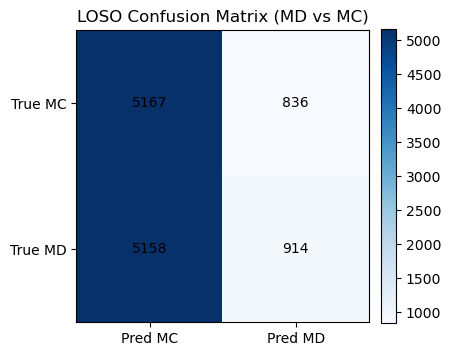

In [11]:
# Confusion matrix plot (aggregated across held-out predictions)
tn = int(np.sum((y_true_all == 0) & (y_pred_all == 0)))
fp = int(np.sum((y_true_all == 0) & (y_pred_all == 1)))
fn = int(np.sum((y_true_all == 1) & (y_pred_all == 0)))
tp = int(np.sum((y_true_all == 1) & (y_pred_all == 1)))
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred MC", "Pred MD"])
ax.set_yticks([0, 1], labels=["True MC", "True MD"])
ax.set_title("LOSO Confusion Matrix (MD vs MC)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


We trained a simple model to classify **MD (understood lyrics)** vs **MC (instrumental)** using:
- `beta_frontal`, `alpha_parocc`, and `focus_index`

We use **Leave-One-Subject-Out (LOSO)** to test generalization across people.

**Result:** Overall accuracy is ~0.51 and AUC is ~0.51 (near chance).  
The confusion matrix shows substantial confusion between MD and MC.

### What this implies
- These coarse bandpower features are **not sufficient** to reliably identify “lyrics vs instrumental” across subjects in this dataset.
- This is consistent with the null group-level statistics: if there were a strong condition signal in these features, LOSO should typically exceed chance.


## 11) Final Report Summary Cell

Use this output directly in slides/writeup as your concise result summary.


In [12]:
p_focus = float(focus_aov_tbl.loc[focus_aov_tbl["effect"] == "condition", "Pr > F"].iloc[0])
p_alpha = float(alpha_aov_tbl.loc[alpha_aov_tbl["effect"] == "condition", "Pr > F"].iloc[0])
acc = float(loso_overall["accuracy"].iloc[0])
auc = float(loso_overall["auc"].iloc[0])

print("Summary")
print("-------")
print("Subjects analyzed:", epoch_df["subject"].nunique())
print("Epochs analyzed (MC/MD/MF):", len(epoch_df))
print("Focus Index rmANOVA p:", round(p_focus, 6))
print("Alpha Stability rmANOVA p:", round(p_alpha, 6))
print("LOSO MD-vs-MC accuracy:", round(acc, 3))
print("LOSO MD-vs-MC AUC:", round(auc, 3))

if p_focus >= 0.05 and p_alpha >= 0.05:
    print("Interpretation: no significant condition effects at alpha=0.05 for these metrics.")
else:
    print("Interpretation: at least one tested metric shows a significant condition effect.")


Summary
-------
Subjects analyzed: 18
Epochs analyzed (MC/MD/MF): 17940
Focus Index rmANOVA p: 0.257974
Alpha Stability rmANOVA p: 0.212106
LOSO MD-vs-MC accuracy: 0.504
LOSO MD-vs-MC AUC: 0.514
Interpretation: no significant condition effects at alpha=0.05 for these metrics.


## Discussion + limitations (what we think is happening)

### Discussion of Findings
Our project set out to determine if background lyrics create a measurable "cognitive tug-of-war" in the brain compared to instrumental music. After analyzing EEG data from 18 subjects, our main findings are as follows:
- Hypothesis vs. Reality: We initially predicted that understood lyrics (Danish) would lower a person’s "Focus Index" (the ratio of Beta to Alpha waves) compared to instrumental music (Cello). However, our statistical analysis (Repeated-Measures ANOVA) showed no significant difference between these conditions ($p \approx 0.258$).
- Alpha Stability: We also looked at how "steady" Alpha waves were during the tasks, thinking lyrics might make brain activity more erratic. Again, the results were statistically inconclusive ($p \approx 0.212$), meaning the brain's rhythm remained relatively similar across all audio types.
- Machine Learning Performance: We trained a computer model to see if it could tell—just by looking at brainwaves—whether a person was listening to Danish lyrics or instrumental music. The model was accurate only about 50.9% of the time, which is essentially the same as guessing with a coin flip.

### Why Did We Get These Results?
Several factors likely played a role:
- Passive vs. Active Listening: The participants in this dataset may have been listening passively. Without a difficult primary task (like a math test) to compete for their attention, the brain might not have been "stressed" enough for the linguistic interference to show up in simple wave measurements.
- Measuring average Alpha and Beta power is a broad approach. It’s possible that the interference is happening in very specific, tiny windows of time or in brain regions (like the temporal lobes) that we didn't focus on as heavily in this specific analysis.
- Everyone processes music and language differently. Some people find lyrics highly distracting, while others can "tune them out" completely. When we average everyone together, these individual differences can cancel each other out.

### Future Work
To build on these findings, future studies could improve the experimental design in the following ways:
- Introduce a "Focus Task": Future experiments should require participants to perform a high-difficulty cognitive task (like an N-back memory test) while the music plays. This would force the brain to choose between the task and the lyrics, likely making the "interference" much easier to see on an EEG.
- Instead of looking at general power, future researchers could use "Speech Tracking" or "Envelope Following". This measures how closely the brain’s electrical activity mimics the physical shape of the speech sounds, providing a much more detailed map of attention.
- Future models should account for a person's familiarity with the language being sung. A person who speaks Danish will likely show a very different brain response to Danish lyrics than someone who does not understand the language at all.